In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Read the dataset**

In [111]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

# **Print the data**

In [112]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Data preprocessing**

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [135]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [210]:
df['Age']=df['Age'].interpolate()
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(0,inplace=True)
df.isnull().sum()

/tmp/ipykernel_1483/377791676.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_1483/377791676.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Data Visualization**

## **Survived passengers**

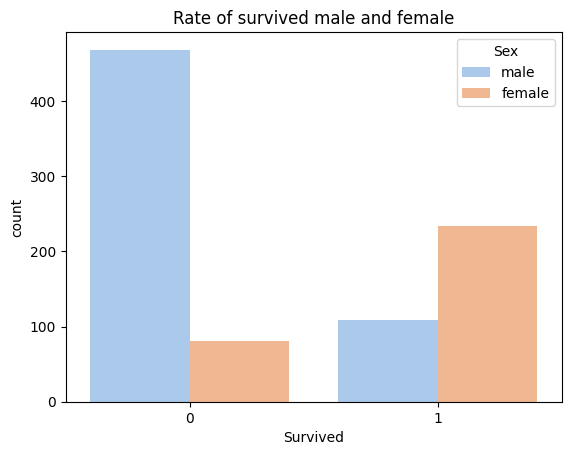

In [116]:
CP=sns.countplot(x='Survived',data=df, hue="Sex", palette="pastel")
CP.set(title="Rate of survived male and female")
plt.show()

Male passengers lost their lives more than the female passenger




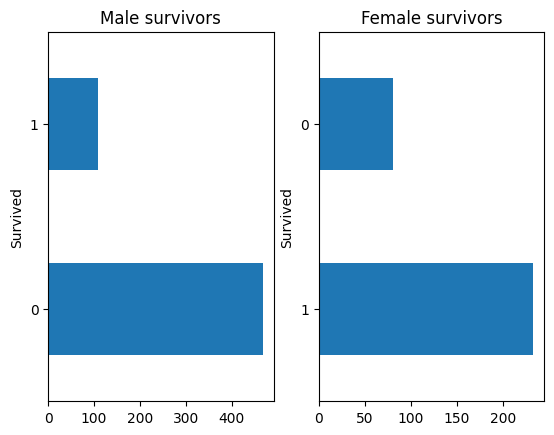

Survived
0    468
1    109
Name: count, dtype: int64
Survived
1    233
0     81
Name: count, dtype: int64


In [209]:
fig, axis = plt.subplots(1,2)
df[df.Sex == "male"].Survived.value_counts().plot(kind="barh", ax=axis[0], title="Male survivors")
df[df.Sex == "female"].Survived.value_counts().plot(kind="barh", ax=axis[1], title="Female survivors")
plt.show()
print(df[df.Sex == "male"].Survived.value_counts())
print(df[df.Sex == "female"].Survived.value_counts())

Total of 468 Men and 233 women lost their lives in titatic accident

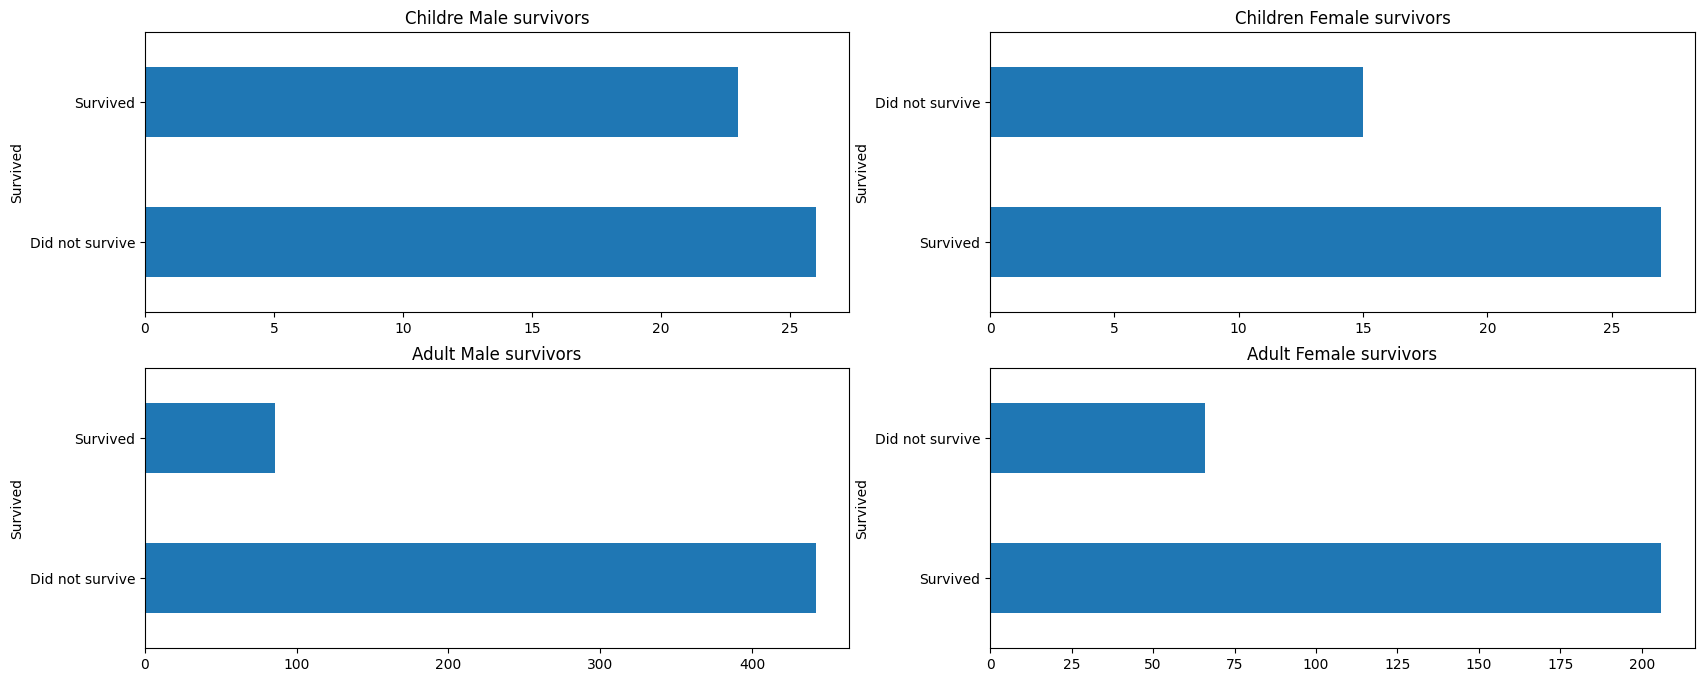

<Figure size 500x800 with 0 Axes>

Survived
0    26
1    23
Name: count, dtype: int64
Survived
1    27
0    15
Name: count, dtype: int64
Survived
0    442
1     86
Name: count, dtype: int64
Survived
1    206
0     66
Name: count, dtype: int64


In [212]:
fig, axis = plt.subplots(2,2, figsize=(20, 8))
plt.figure(figsize=(5,8))
labels_map = {0: "Did not survive", 1: "Survived"}
df[(df.Sex == "male") & (df.Age<15)].Survived.value_counts().rename(index=labels_map).plot(kind="barh", ax=axis[0][0], title="Childre Male survivors")
df[(df.Sex == "female") & (df.Age<15)].Survived.value_counts().rename(index=labels_map).plot(kind="barh", ax=axis[0][1], title="Children Female survivors")
df[(df.Sex == "male") & (df.Age>=15)].Survived.value_counts().rename(index=labels_map).plot(kind="barh", ax=axis[1][0], title="Adult Male survivors")
df[(df.Sex == "female") & (df.Age>=15)].Survived.value_counts().rename(index=labels_map).plot(kind="barh", ax=axis[1][1], title="Adult Female survivors")

plt.show()
print(df[(df.Sex == "male") & (df.Age<15)].Survived.value_counts())
print(df[(df.Sex == "female") & (df.Age<15)].Survived.value_counts())
print(df[(df.Sex == "male") & (df.Age>=15)].Survived.value_counts())
print(df[(df.Sex == "female") & (df.Age>=15)].Survived.value_counts())

Maximum of male adults (442) lost their lives with 206 women adults.
Among kids, 23 boys and 15 girls lost their lives

## **Paseenger Class**

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


[]

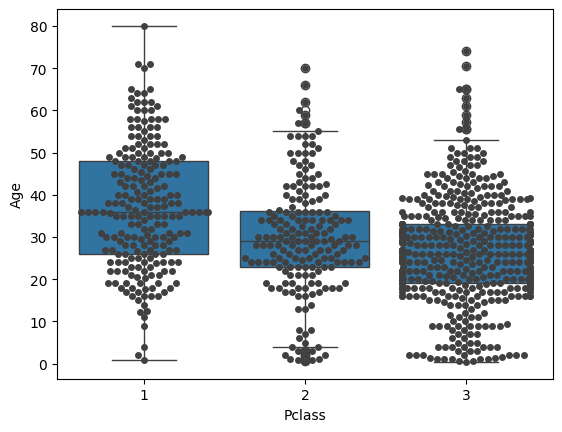

In [117]:
sns.boxplot(x='Pclass',y="Age",data=df)
sns.swarmplot(x='Pclass',y="Age",data=df, color=".25")
plt.plot()

<Axes: xlabel='Pclass', ylabel='Fare'>

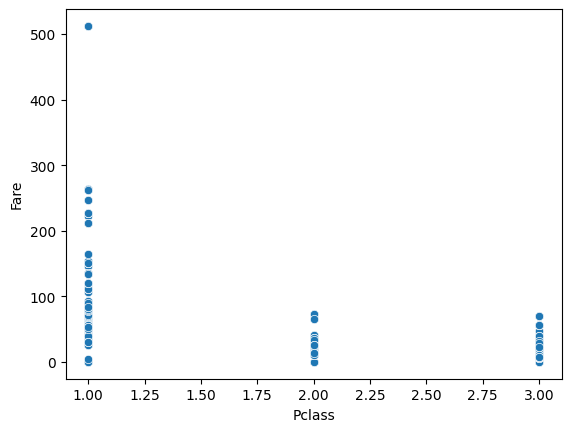

In [118]:
sns.scatterplot(x="Pclass",y="Fare", data=df)

In [215]:
df[['Pclass','Survived','Sex']].groupby(['Pclass','Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Sex,Survived
0,1,female,0.968085
2,2,female,0.921053
4,3,female,0.500000
1,1,male,0.368852
3,2,male,0.157407
5,3,male,0.135447


Female employees in Passenger class 1 and 2 survived the most

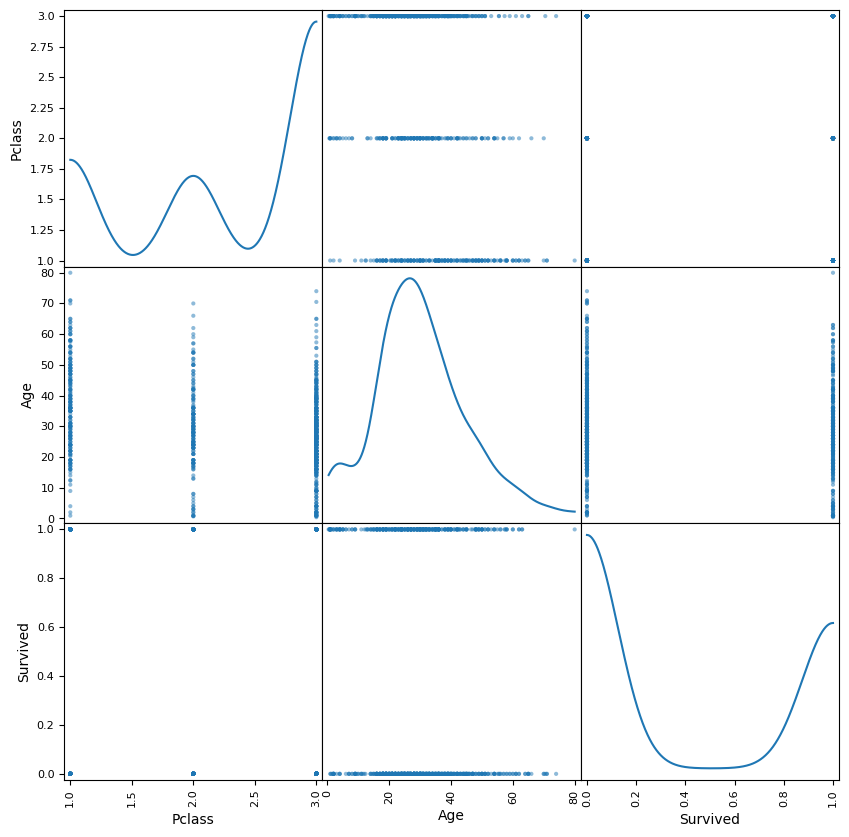

In [231]:
cols=['Pclass', 'Age','Survived']
pd.plotting.scatter_matrix(df[cols], figsize=(10,10), diagonal='kde')
plt.show()